# T Gate Estimation

# Project 8: Quantum Phase Estimation (QPE) - T-Gate Estimation

**Objective:** Build a QPE circuit to measure the unknown phase ($\theta$) applied by a Unitary operator ($U$) to its eigenstate.

**The Theory (80/20):**
We are going to probe a $T$-gate. The $T$-gate adds a phase of $e^{i \pi / 4}$ to the $|1\rangle$ state.
Because a full rotation is $2\pi$, a phase of $\pi/4$ corresponds to exactly $1/8$ of a full circle ($\theta = 1/8$).

To estimate a fraction with a denominator of $8$, we need $2^3 = 8$ distinct measurement states. Thus, our architecture requires **3 counting qubits** (the sensor) and **1 target qubit** (the eigenstate).

**The Architecture:**
1. **Initialize:** Put the target qubit in the $|1\rangle$ state. Put the 3 counting qubits in a superposition.
2. **Phase Kickback:** Use controlled-$U$ operations to kick the phase of the $T$-gate up into the counting qubits.
3. **Decode:** Apply the Inverse QFT (from Project 7) to translate the phase rotations back into classical 0s and 1s.

In [1]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from IPython.display import display
import numpy as np

# Re-using our Inverse QFT from Project 7
def build_iqft(n: int) -> QuantumCircuit:
    qc = QuantumCircuit(n, name="IQFT")
    for i in range(n // 2):
        qc.swap(i, n - 1 - i)
    for i in range(n):
        for j in range(i):
            qc.cp(-np.pi / (2 ** (i - j)), j, i)
        qc.h(i)
    return qc

print("Environment Ready.")

Environment Ready.


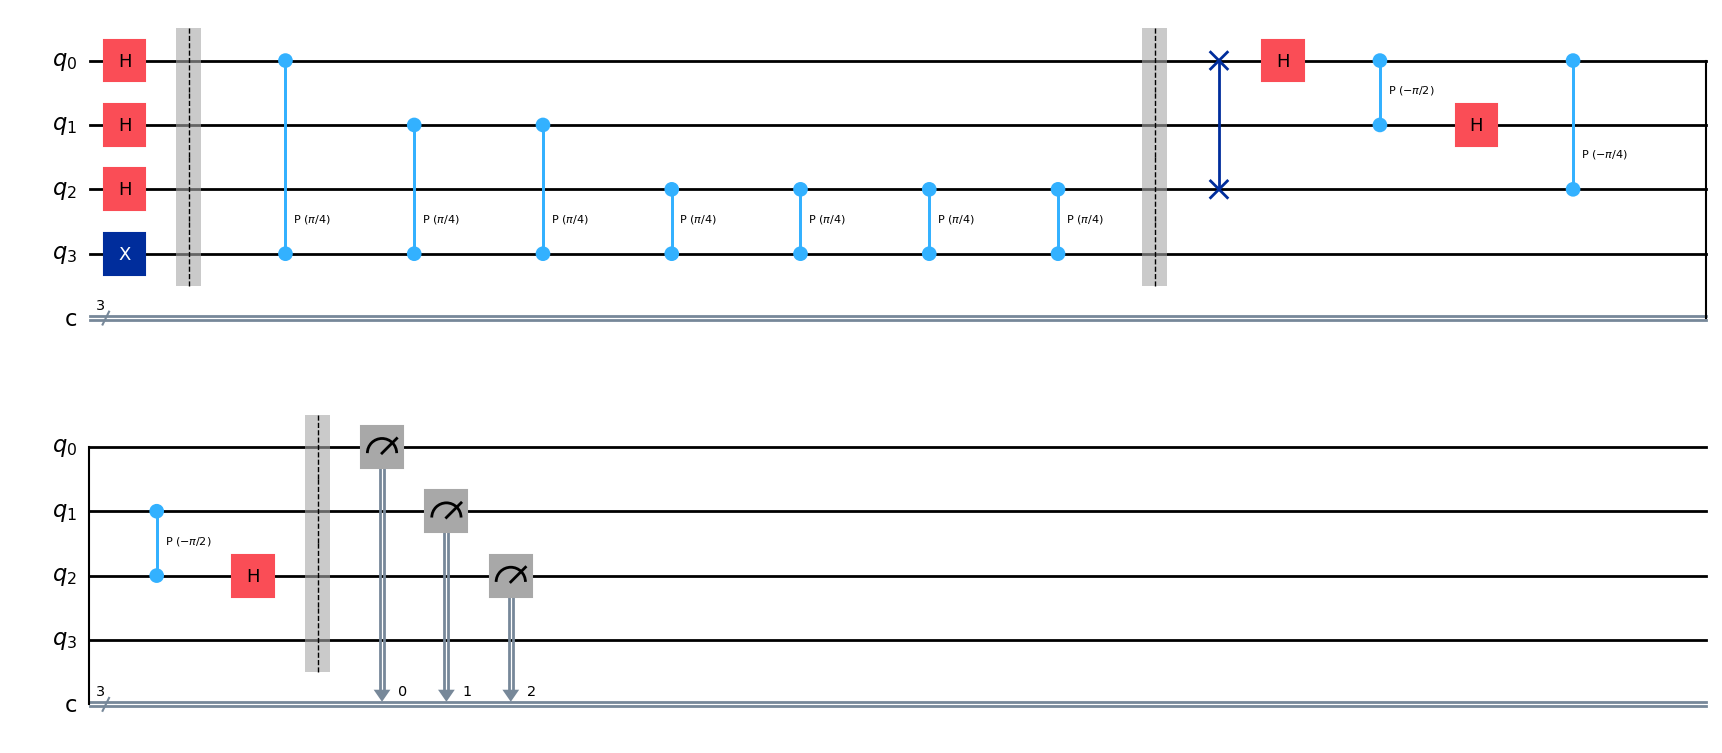

In [2]:
# 3 counting qubits (Sensor) + 1 target qubit (State)
n_counting_qubits = 3
total_qubits = n_counting_qubits + 1

qc = QuantumCircuit(total_qubits, n_counting_qubits)

# Step 1: Initialization
# Prepare the target qubit in the eigenstate |1> of the T-gate
qc.x(3) 

# Apply Hadamards to the counting qubits to create our probing superposition
for i in range(n_counting_qubits):
    qc.h(i)
    
qc.barrier()

# Step 2: The Controlled-U Operations (Phase Kickback)
# The T-gate rotates by pi/4. We apply C-U^(2^i) for each counting qubit.
angle = np.pi / 4

for counting_qubit in range(n_counting_qubits):
    # Number of times we apply the gate is 2^i
    repetitions = 2 ** counting_qubit
    for _ in range(repetitions):
        # Apply controlled-phase (C-U) from the counting qubit to the target
        qc.cp(angle, counting_qubit, 3)

qc.barrier()

# Step 3: The Decoder
# Apply the Inverse QFT to the counting qubits only
qc.compose(build_iqft(n_counting_qubits), qubits=range(n_counting_qubits), inplace=True)

qc.barrier()

# Step 4: Measurement
# Map the quantum sensor readings to classical bits
qc.measure(range(n_counting_qubits), range(n_counting_qubits))

display(qc.draw('mpl'))

Measurement Output: {'001': 1024}


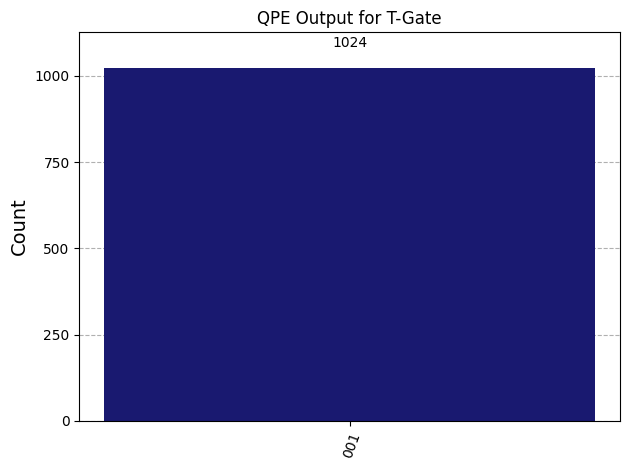

In [3]:
# Execute using the V2 Sampler
sampler = StatevectorSampler()
job = sampler.run([qc], shots=1024)
pub_result = job.result()[0]
counts = pub_result.data.c.get_counts()

print(f"Measurement Output: {counts}")
display(plot_histogram(counts, title="QPE Output for T-Gate", color='midnightblue'))

## Final Analysis: Decoding the Phase

**What did we just observe?**
When you look at the histogram, you should see exactly one result with 100% certainty: `001`. 

**What does `001` mean?**
This is where the magic happens. The output is a binary integer representing our hidden phase. 
1. Convert the binary string `001` to a decimal integer: **1**.
2. Divide that integer by the total number of possible states in our sensor ($2^n$, where $n=3$ counting qubits).
3. The math: $1 / 2^3 = 1 / 8$.

**The QPE algorithm perfectly predicted that the hidden phase of the T-Gate was $1/8$!** **Why does this matter for our roadmap?**
You have just built the ultimate quantum measuring instrument. Phase Estimation is the quantum subroutine that proves quantum computers can find the underlying patterns (eigenvalues/periods) inside incredibly complex operators faster than classical supercomputers. 

Because we can extract these hidden numerical fractions, we can now find the period of mathematical functions. This is the exact stepping stone we need for **Shor's Algorithm**, where we will use this very logic to crack RSA encryption.